In [1]:
import sys
sys.path.append('../../')
from PreprocessingMethods import StandardPreprocessor, DWTPreprocessor
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from IPython.display import clear_output

In [2]:
df = pd.read_csv("hf://datasets/CitrusBoy/EnergyPriceForecasting/final_dataset_full_clean_with_gas_no_processing.csv")
df["time"] = pd.to_datetime(df["time"])

# Standard Preprocessor

This is how the Standard Preprocessor (yes, the one mentioned on the proposal) to be used on Exp 2.

In [ ]:
X = df.drop("price", axis=1)

# there would be a y in the real case

In [4]:
st = StandardPreprocessor()

X = st.transform(X)

In [6]:
X.describe()

,temperature_2m,cloud_cover,wind_speed_10m,shortwave_radiation,total_load,generation_forecast,Price,Open,High,Low,...,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,weekend_sin,weekend_cos
count,96133.000000,96133.000000,96133.000000,96133.000000,96133.000000,96133.000000,49488.000000,49488.000000,49488.000000,49488.000000,...,96133.000000,9.613300e+04,96133.000000,96133.000000,9.613300e+04,9.613300e+04,9.613300e+04,9.613300e+04,9.613300e+04,96133.000000
mean,0.478215,0.668799,0.240067,0.145746,0.556883,0.172929,0.114258,0.113726,0.114952,0.112734,...,-0.000060,-9.944924e-05,0.000590,0.000590,-6.602035e-03,-2.887859e-03,-6.844684e-03,3.255906e-03,3.493440e-17,0.429478
std,0.137524,0.319590,0.128979,0.221190,0.118048,0.162676,0.126408,0.126301,0.126960,0.125723,...,0.707131,7.070897e-01,0.707068,0.707152,7.057543e-01,7.084273e-01,7.059841e-01,7.081944e-01,5.529783e-17,0.903082
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,-1.000000
25%,0.375884,0.430000,0.141149,0.000000,0.481716,0.052298,0.043136,0.042504,0.042464,0.042822,...,-0.707107,-7.071068e-01,-0.781831,-0.900969,-8.660254e-01,-8.660254e-01,-1.000000e+00,-1.836970e-16,0.000000e+00,-1.000000
50%,0.473181,0.758000,0.216352,0.006545,0.544884,0.121031,0.076709,0.076491,0.077435,0.075150,...,0.000000,-1.836970e-16,0.000000,-0.222521,-2.449294e-16,-1.836970e-16,-2.449294e-16,-1.836970e-16,0.000000e+00,1.000000
75%,0.578378,0.974000,0.313536,0.229519,0.635310,0.244744,0.117872,0.117513,0.119727,0.115641,...,0.707107,7.071068e-01,0.781831,0.623490,5.000000e-01,8.660254e-01,1.224647e-16,1.000000e+00,1.224647e-16,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.224647e-16,1.000000


# Discrete Wavelet Transformer

In [3]:
cutoff_date = df[df['Price'].isna() == False]['time'].iloc[0]

In [4]:
df = df[df['time'] > cutoff_date]

df.interpolate(method='linear', inplace=True)

In [5]:
dwt = DWTPreprocessor()

df_dwt = dwt.transform(df)

In [6]:
df_dwt

,time,price,temperature_2m,cloud_cover,wind_speed_10m,shortwave_radiation,total_load,generation_forecast,Price,Open,...,High_d3,Low_d1,Low_d2,Low_d3,Change %_d1,Change %_d2,Change %_d3,price_d1,price_d2,price_d3
24382,2017-10-23 01:00:00,31.85,10.80,0.944,18.88,0.0,10402.3200,2161.50,18.090,18.090,...,-4.912922e-11,0.000425,5.177427e-11,-5.030456e-11,-0.095651,-9.368577e-11,7.901501e-11,0.076232,-0.098714,-0.026504
24383,2017-10-23 02:00:00,33.64,10.94,0.894,19.36,0.0,10233.4975,1830.50,18.090,18.090,...,4.913140e-11,0.001210,1.410847e-11,5.030705e-11,-0.272242,-2.553011e-11,-7.901484e-11,0.132801,-0.065357,0.120988
24384,2017-10-23 03:00:00,34.00,10.86,0.838,20.56,0.0,10269.2100,1870.25,18.090,18.090,...,-4.912922e-11,0.001908,2.031570e-06,-5.030456e-11,-0.429372,-5.033100e-04,7.901501e-11,0.181892,-0.000989,-0.017558
24385,2017-10-23 04:00:00,34.10,11.00,0.902,20.04,0.0,10413.8225,1922.50,18.090,18.090,...,4.913140e-11,0.001138,-7.946766e-07,5.030705e-11,-0.256080,1.968682e-04,-7.901484e-11,0.127455,0.031508,-0.042369
24386,2017-10-23 05:00:00,34.00,10.98,0.998,21.80,0.0,11004.6450,1996.50,18.090,18.090,...,-4.912922e-11,0.000064,-7.050264e-06,-5.030456e-11,-0.014301,1.746632e-03,7.901501e-11,0.032400,0.052582,-0.054936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96128,2025-12-31 19:00:00,89.71,3.54,0.898,15.92,0.0,14675.8875,1953.75,28.161,27.755,...,-7.721091e-11,0.000059,-6.732012e-08,-7.718376e-11,-0.014709,1.835174e-05,-2.503909e-12,0.215567,-0.647939,0.113305
96129,2025-12-31 20:00:00,89.19,3.14,0.964,16.78,0.0,13869.5125,1971.75,28.161,27.755,...,7.721281e-11,0.000092,-1.719281e-07,7.718625e-11,-0.022802,4.691777e-05,2.504081e-12,0.072777,-0.335779,0.057115
96130,2025-12-31 21:00:00,89.89,3.06,0.940,17.92,0.0,12952.0750,1986.25,28.161,27.755,...,-7.720745e-11,0.000098,7.944121e-11,-7.718376e-11,-0.024285,2.968970e-12,-2.503927e-12,-0.080011,0.352353,-0.416446
96131,2025-12-31 22:00:00,87.16,3.12,0.976,18.72,0.0,12017.9475,2043.50,28.161,27.755,...,7.720779e-11,0.000096,2.164624e-11,7.718625e-11,-0.023857,8.092035e-13,2.504088e-12,-0.327365,0.070040,0.576085


In [7]:
_dimensionGroups= [['temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation'], ['total_load', 'generation_forecast', 'Price', 'High', 'Low', 'Change %', 'price']]


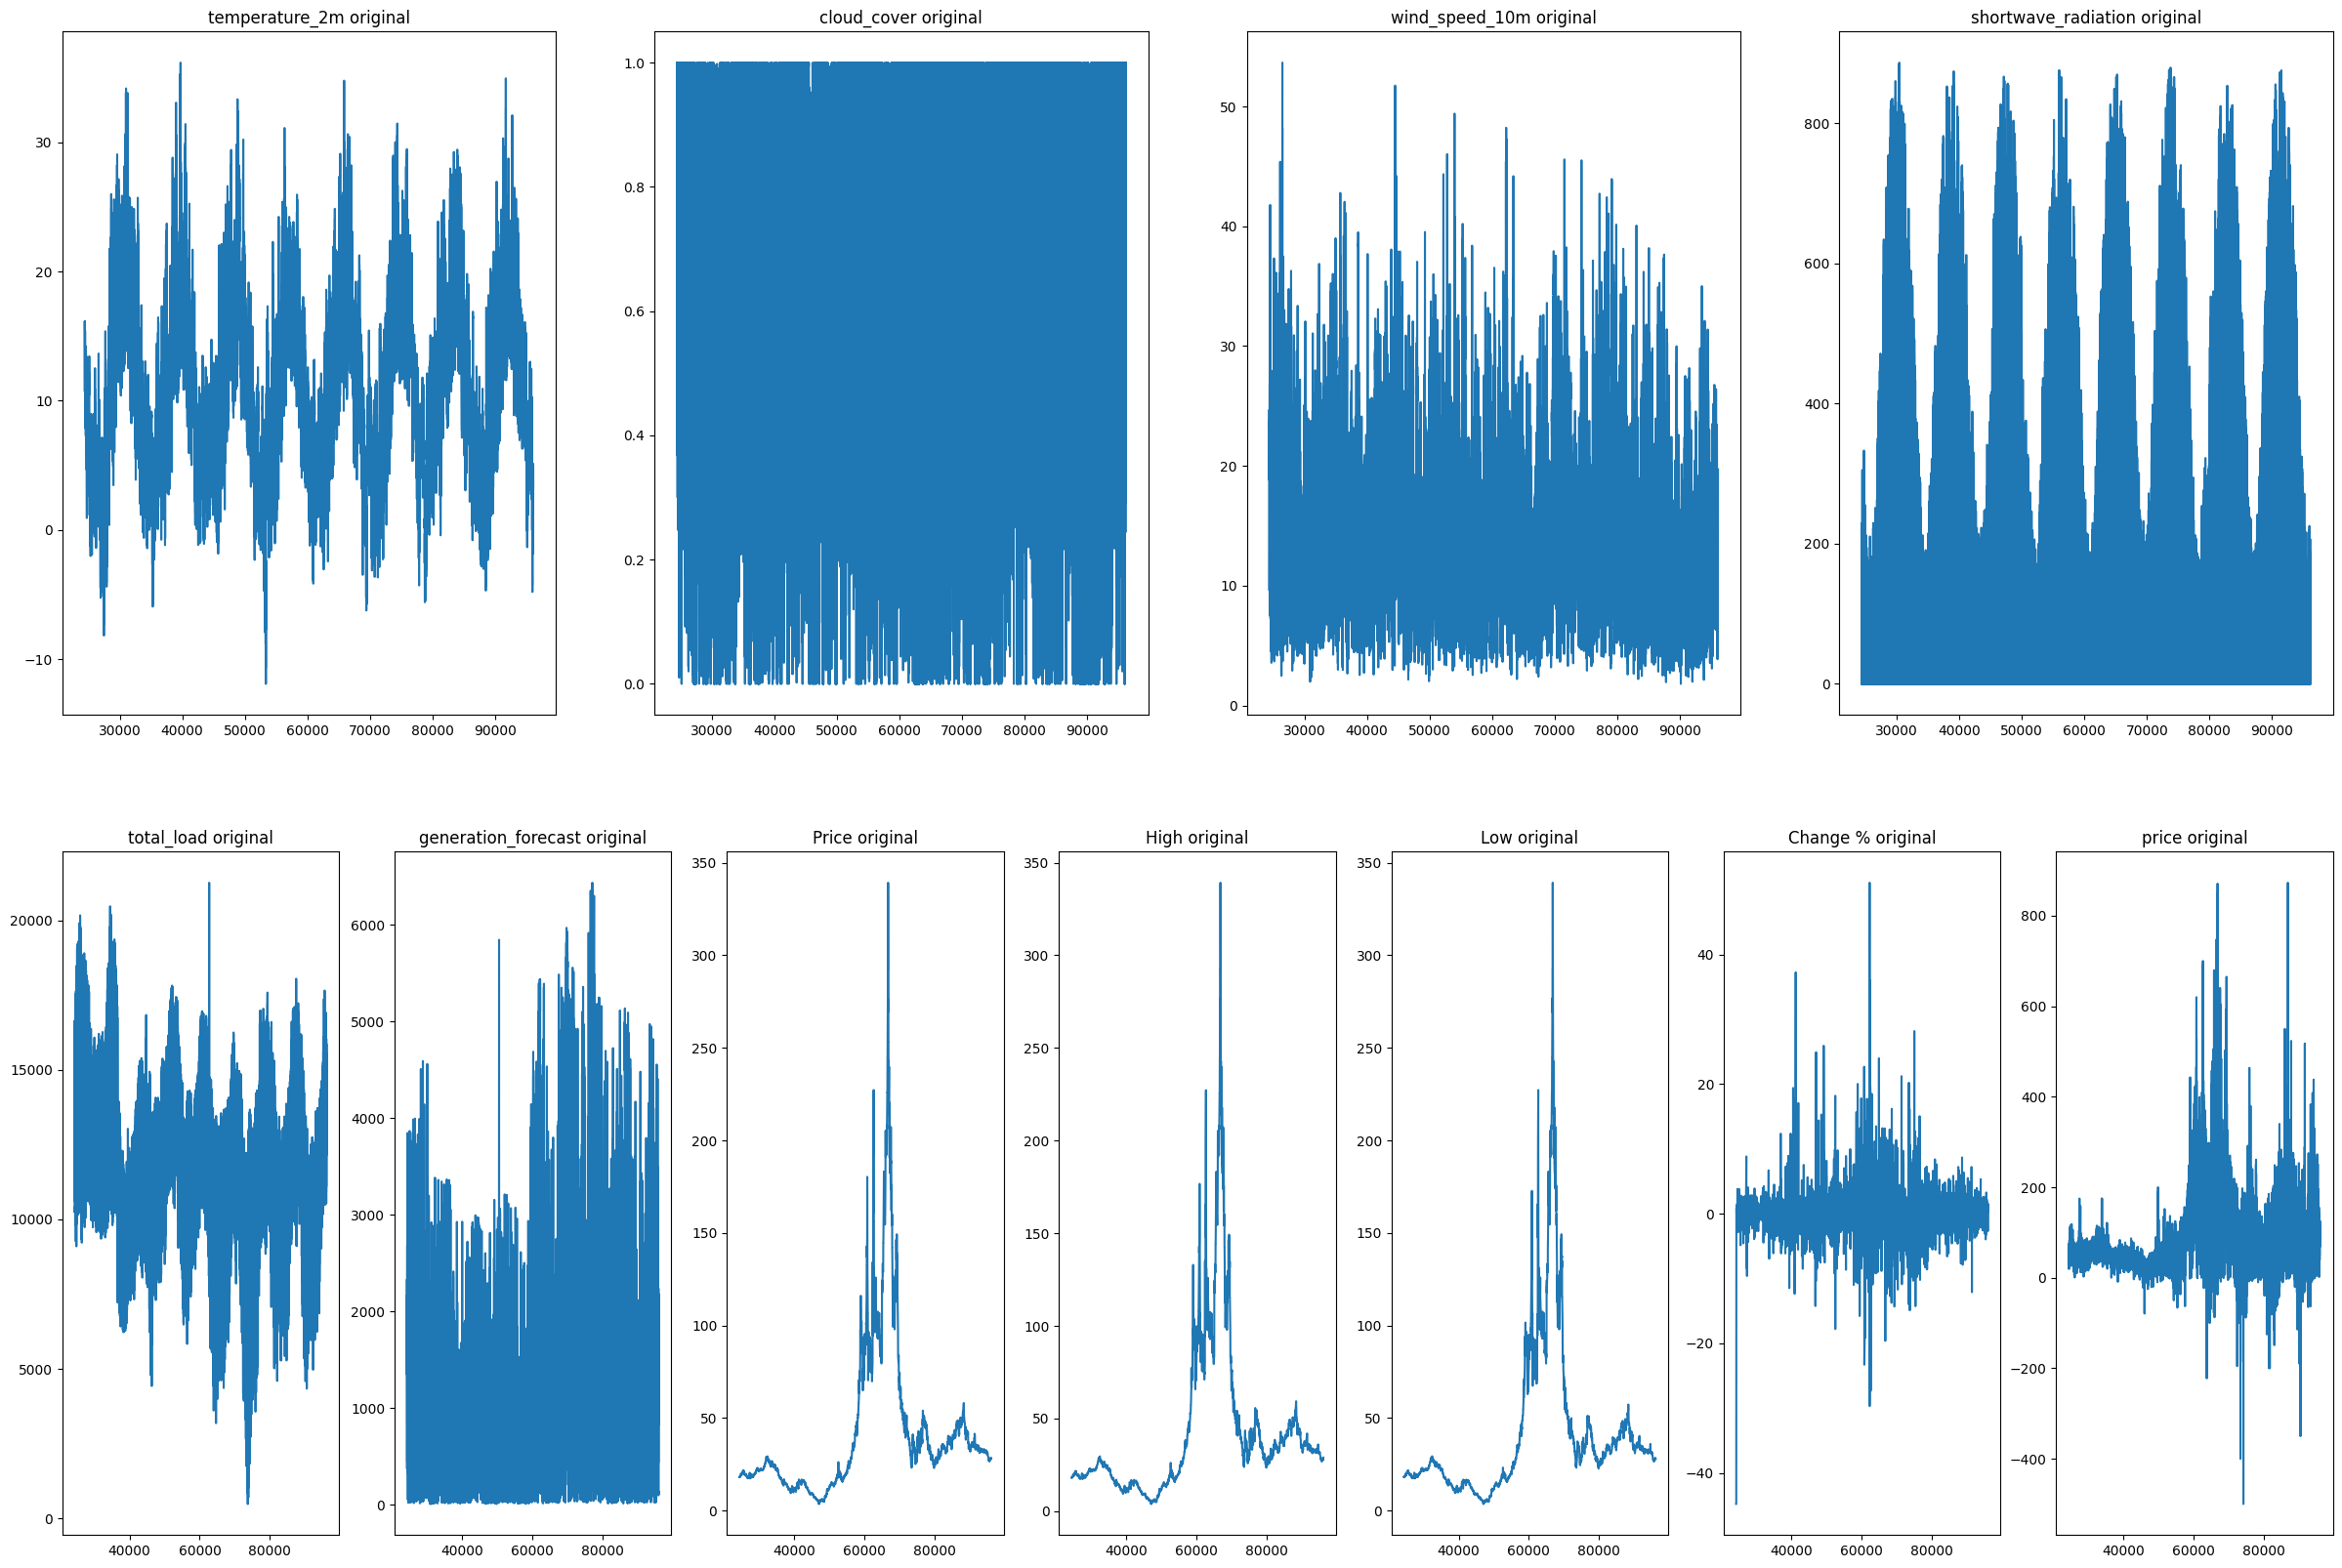

In [8]:
plt.figure(figsize=(30, 20))
for i, group in enumerate(_dimensionGroups):
    for j, name in enumerate(group):
        plt.subplot(len(_dimensionGroups), len(group), i*len(group) + j + 1)
        plt.plot(df_dwt[name])
        plt.title(name + " original")

## TODO: Feature Selection based on noise. Which Decompositions we want to keep

for what its worth, cloud_cover should just dissapear. it is pointless noise which we know from EDA is not statistically significant. At the very least, not decomposition feature from cloud cover should be included.

for temp, d2 and d3 looks ok. maybe drop d1

for wind, d2 (maybe), should be tested with, seems fairly useless

shortwave radiation looks sctuctured on both signals, but especially d3, so again, d2 and d3

for total_load, d3 and maybe d2. same for gen_forecast


Change%, their decomposition can be dropped

If we really want to try-hard this, we could totally do hyperparameter tunning but it could take like a week if we automate the process xD although... this would be better option

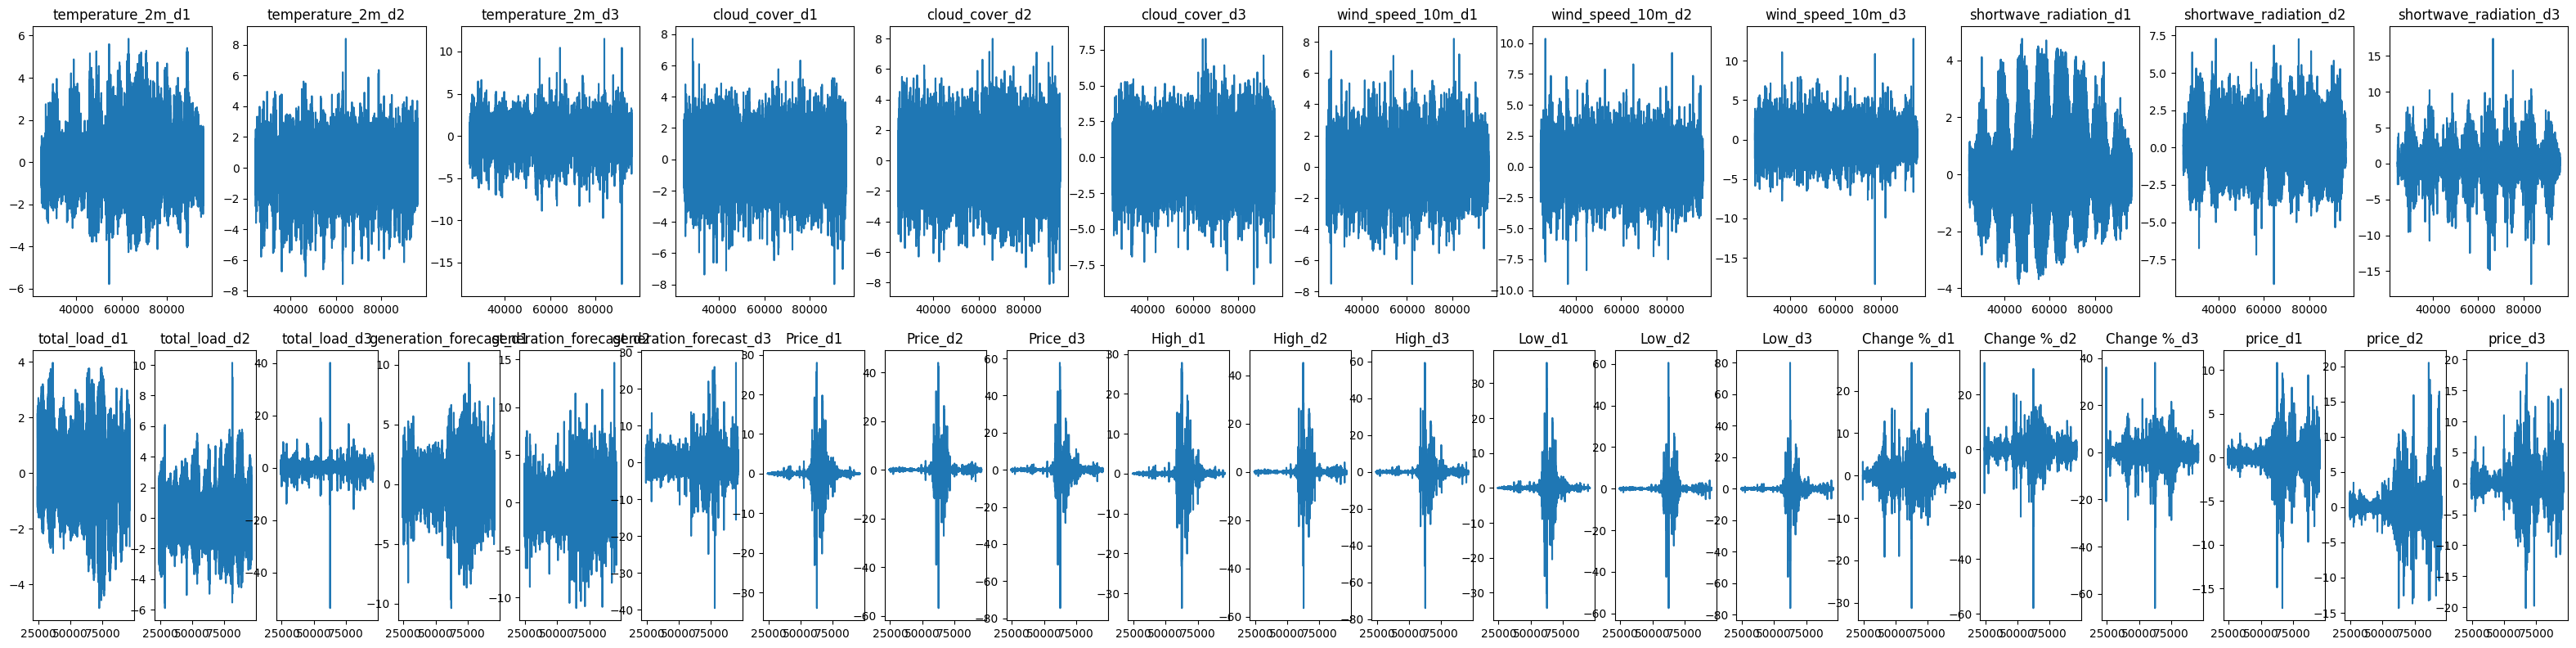

In [9]:
plt.figure(figsize=(40, 30))
for i, group in enumerate(_dimensionGroups):
    for j, name in enumerate(group):
        for id in range(1, 4):
            plt.subplot(len(_dimensionGroups)*3, len(group)*3, i*len(group)*3 + j*3 + id)
            plt.plot(df_dwt[name + f'_d{id}'])
            plt.title(name + f'_d{id}')

## Ablation

Ablation is when you remove a feature from the overall system and you observe the differences that the removal produces. That analysis might yield the conclusion that a particular feature should not be included in the overall model.

In [10]:
for col in df_dwt.columns:
    if col != "price" and col != "time":
        for lag in range(1, 25): 
            df_dwt[f"{col}_lag{lag}"] = df_dwt[col].shift(lag)

df_dwt['target'] = df_dwt['price'].shift(-24)

C:\Users\User\AppData\Local\Temp\ipykernel_28508\4170355165.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dwt[f"{col}_lag{lag}"] = df_dwt[col].shift(lag)
C:\Users\User\AppData\Local\Temp\ipykernel_28508\4170355165.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dwt[f"{col}_lag{lag}"] = df_dwt[col].shift(lag)
C:\Users\User\AppData\Local\Temp\ipykernel_28508\4170355165.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

In [11]:
non_lag_cols = [c for c in df_dwt.columns if '_lag' not in c and c not in ['target', 'time']]
df_dwt = df_dwt.drop(columns=non_lag_cols)
df_dwt = df_dwt.dropna().reset_index(drop=True)

In [12]:
train = df_dwt.iloc[:int(len(df_dwt)*0.7)]
val   = df_dwt.iloc[int(len(df_dwt)*0.7):int(len(df_dwt)*0.85)]
test  = df_dwt.iloc[int(len(df_dwt)*0.85):]

X_train = train.drop(columns=['target', 'time'])
y_train = train['target']
X_val = val.drop(columns=['target', 'time'])
y_val = val['target']

In [14]:
def train_eval(X_train, y_train, X_val, y_val):
    model = LGBMRegressor(n_estimators=300, learning_rate=0.05)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    return rmse, model

In [15]:
baseline_rmse, baseline_model = train_eval(
    X_train, y_train, X_val, y_val
)

baseline_rmse

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 270096
[LightGBM] [Info] Number of data points in the train set: 50192, number of used features: 1176
[LightGBM] [Info] Start training from score 93.330019


33.506869817188644

### per feature

In [35]:
def ablation_feature(X_train, X_val, y_train, y_val, baseline_rmse):
    results = []

    distinct_features = set([col.split('_')[0] for col in X_train.columns])
    for col in distinct_features:
        cols =[[elem for elem in X_train.columns if col in elem]][0]
        X_train_drop = X_train.drop(columns=cols)
        X_val_drop   = X_val.drop(columns=cols)

        rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

        results.append({
            "feature": col,
            "rmse": rmse,
            "delta": rmse - baseline_rmse
        })

    clear_output()
    return pd.DataFrame(results).sort_values("delta", ascending=False)

Temporal features are the most benefitial, followed by temperature (im surprised), price (ah duhh), Low (lowest gas price)(????), total generation. Wind is really far bellow

In [36]:
ablation_feature(X_train, X_val, y_train, y_val, baseline_rmse)

,feature,rmse,delta
9,time,35.445261,1.938391
2,temperature,33.910776,0.403906
3,price,33.818318,0.311448
12,Low,33.765721,0.258851
0,total,33.711366,0.204496
4,shortwave,33.622666,0.115796
5,wind,33.596264,0.089395
11,High,33.536013,0.029143
7,cloud,33.460034,-0.046836
1,Open,33.371525,-0.135344


### per band

In [41]:
def ablation_by_band(X_train, X_val, y_train, y_val, baseline_rmse):
    bands = {
        "d1": [c for c in X_train.columns if "_d1" in c],
        "d2": [c for c in X_train.columns if "_d2" in c],
        "d3": [c for c in X_train.columns if "_d3" in c],
    }

    results = []

    for band, cols in bands.items():
        if not cols:
            continue

        X_train_drop = X_train.drop(columns=cols)
        X_val_drop   = X_val.drop(columns=cols)

        rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

        results.append({
            "band": band,
            "rmse": rmse,
            "delta": rmse - baseline_rmse,
            "n_features_removed": len(cols)
        })

    clear_output()

    return pd.DataFrame(results).sort_values("delta", ascending=False)

Seems like d2 is the likely better one

In [42]:
ablation_by_band(X_train, X_val, y_train, y_val, baseline_rmse)

,band,rmse,delta,n_features_removed
1,d2,33.473964,-0.032906,264
0,d1,33.455149,-0.051721,264
2,d3,33.412654,-0.094216,264


## per variable

In [39]:
def ablation_per_variable_band(X_train, X_val, y_train, y_val, baseline_rmse):
    results = []

    base_vars = set([c.split("_d")[0] for c in X_train.columns if "_d" in c])

    for var in base_vars:
        for band in ["d1", "d2", "d3"]:
            cols = [c for c in X_train.columns if c.startswith(var) and f"_{band}" in c]

            if not cols:
                continue

            X_train_drop = X_train.drop(columns=cols)
            X_val_drop   = X_val.drop(columns=cols)

            rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

            results.append({
                "variable": var,
                "band": band,
                "rmse": rmse,
                "delta": rmse - baseline_rmse
            })

    clear_output()

    return pd.DataFrame(results).sort_values("delta", ascending=False)

Ok really interesting stuff here. That total_load, specifically d2, ranked the highest is impressive.

In [40]:
ablation_per_variable_band(X_train, X_val, y_train, y_val, baseline_rmse)

,variable,band,rmse,delta
16,total_load,d2,33.756189,0.249319
9,generation_forecast,d1,33.642795,0.135925
0,price,d1,33.632644,0.125774
20,temperature_2m,d3,33.614782,0.107912
31,Low,d2,33.605844,0.098975
8,wind_speed_10m,d3,33.603512,0.096642
14,Price,d3,33.599684,0.092814
1,price,d2,33.589829,0.082959
28,cloud_cover,d2,33.589608,0.082739
17,total_load,d3,33.579247,0.072377
